In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
nu_true = 0.01 / np.pi

def exact_burgers(x, t, nu=nu_true):
    if t == 0:
        return -np.sin(np.pi * x)
    def integrand_num(eta):
        return np.sin(np.pi * eta) * \
               np.exp(-np.cos(np.pi * eta) / (2 * np.pi * nu)) * \
               np.exp(-(x - eta)**2 / (4 * nu * t))
    def integrand_den(eta):
        return np.exp(-np.cos(np.pi * eta) / (2 * np.pi * nu)) * \
               np.exp(-(x - eta)**2 / (4 * nu * t))
    num, _ = quad(integrand_num, -1, 1, limit=200)
    den, _ = quad(integrand_den, -1, 1, limit=200)
    return -num / den

print(f"True ν: {nu_true:.6f}")

True ν: 0.003183


In [10]:
np.random.seed(42)

N_obs_general = 140
N_obs_shock   = 60

x_obs_general = np.random.uniform(-1, 1, N_obs_general)
t_obs_general = np.random.uniform(0, 1, N_obs_general)

x_obs_shock = np.random.uniform(-0.15, 0.15, N_obs_shock)
t_obs_shock = np.random.uniform(0.6, 1.0, N_obs_shock)

x_obs_np = np.concatenate([x_obs_general, x_obs_shock])
t_obs_np = np.concatenate([t_obs_general, t_obs_shock])

print("Evaluating exact solution at observation points...")
u_obs_np = np.array([exact_burgers(xi, ti) for xi, ti in zip(x_obs_np, t_obs_np)])

x_obs = torch.FloatTensor(x_obs_np).reshape(-1, 1).to(device)
t_obs = torch.FloatTensor(t_obs_np).reshape(-1, 1).to(device)
u_obs_clean = torch.FloatTensor(u_obs_np).reshape(-1, 1).to(device)

print(f"Observation points: {x_obs.shape} ({N_obs_general} general + {N_obs_shock} near-shock)")
print(f"u_obs min: {u_obs_clean.min():.4f}, max: {u_obs_clean.max():.4f}")

Evaluating exact solution at observation points...
Observation points: torch.Size([200, 1]) (140 general + 60 near-shock)
u_obs min: -0.9906, max: 0.9956


In [11]:
N_f_general = 8000
N_f_shock   = 2000

x_f_general = torch.FloatTensor(N_f_general, 1).uniform_(-1, 1)
t_f_general = torch.FloatTensor(N_f_general, 1).uniform_(0, 1)

# FIX: extra collocation points concentrated in the shock region so autograd
# gets accurate u_x, u_xx exactly where nu's effect on the residual is largest.
x_f_shock = torch.FloatTensor(N_f_shock, 1).uniform_(-0.15, 0.15)
t_f_shock = torch.FloatTensor(N_f_shock, 1).uniform_(0.6, 1.0)

x_f = torch.cat([x_f_general, x_f_shock], dim=0).to(device)
t_f = torch.cat([t_f_general, t_f_shock], dim=0).to(device)

# Initial condition: u(x,0) = -sin(πx)
N_ic = 100
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-1, 1).to(device)
t_ic = torch.zeros(N_ic, 1).to(device)
u_ic = -torch.sin(np.pi * x_ic)   # no change — inherits device from x_ic

# Boundary: u(±1, t) = 0
N_bc = 200
x_bc = torch.cat([-torch.ones(N_bc//2, 1), torch.ones(N_bc//2, 1)], dim=0).to(device)
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, 1).to(device)
u_bc = torch.zeros(N_bc, 1).to(device)

In [12]:
class PINN(nn.Module):
    def __init__(self, layers=[2, 100, 100, 100, 100, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'tanh_{i}', nn.Tanh())
        self.net.add_module('output', nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

model = PINN().to(device)

log_nu = torch.nn.Parameter(torch.tensor([np.log(0.05)], dtype=torch.float32,device=device))

def get_nu():
    return torch.exp(log_nu)

optimizer = torch.optim.Adam(list(model.parameters()) + [log_nu], lr=1e-3)

print(f"Initial ν guess: {get_nu().item():.6f}")
print(f"True ν:          {nu_true:.6f}")

Initial ν guess: 0.050000
True ν:          0.003183


In [13]:
def compute_loss(u_obs_tensor, w_data=50.0):
    nu = get_nu()

    x = x_f.requires_grad_(True)
    t = t_f.requires_grad_(True)
    u = model(x, t)

    u_t  = torch.autograd.grad(u, t,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_x  = torch.autograd.grad(u, x,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    loss_pde = torch.mean(residual**2)

    u_pred_obs = model(x_obs, t_obs)
    loss_data  = torch.mean((u_pred_obs - u_obs_tensor)**2)

    u_pred_ic  = model(x_ic, t_ic)
    loss_ic    = torch.mean((u_pred_ic - u_ic)**2)

    u_pred_bc  = model(x_bc, t_bc)
    loss_bc    = torch.mean((u_pred_bc - u_bc)**2)

    return loss_pde + w_data*loss_data + 10*loss_ic + 10*loss_bc

In [14]:
losses = []
nu_history = []

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

for epoch in range(15000):
    optimizer.zero_grad()
    loss = compute_loss(u_obs_clean)
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())
    nu_history.append(get_nu().item())

    if epoch % 1500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | ν estimate: {get_nu().item():.6f}")

print(f"\nAfter Adam -> ν: {get_nu().item():.6f}  (relative error {abs(get_nu().item()-nu_true)/nu_true*100:.2f}%)")

print("\nRefining with L-BFGS (this can take a few minutes)...")
lbfgs = torch.optim.LBFGS(list(model.parameters()) + [log_nu], lr=1.0, max_iter=10000,
                           max_eval=10000, history_size=100, tolerance_grad=1e-12,
                           tolerance_change=1e-14, line_search_fn='strong_wolfe')

def closure():
    lbfgs.zero_grad()
    loss = compute_loss(u_obs_clean)
    loss.backward()
    return loss

lbfgs.step(closure)

final_loss = compute_loss(u_obs_clean).item()
losses.append(final_loss)
nu_history.append(get_nu().item())

print(f"\nTrue ν:      {nu_true:.6f}")
print(f"Recovered ν (after L-BFGS): {get_nu().item():.6f}")
print(f"Relative error: {abs(get_nu().item() - nu_true)/nu_true * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Loss: 26.840784 | ν estimate: 0.049950
Epoch  1500 | Loss: 0.527111 | ν estimate: 0.013980
Epoch  3000 | Loss: 0.086835 | ν estimate: 0.006140
Epoch  4500 | Loss: 0.017710 | ν estimate: 0.004077
Epoch  6000 | Loss: 0.010066 | ν estimate: 0.003570
Epoch  7500 | Loss: 0.007565 | ν estimate: 0.003342
Epoch  9000 | Loss: 0.006455 | ν estimate: 0.003252
Epoch 10500 | Loss: 0.005761 | ν estimate: 0.003215
Epoch 12000 | Loss: 0.005308 | ν estimate: 0.003200
Epoch 13500 | Loss: 0.004947 | ν estimate: 0.003194

After Adam -> ν: 0.003191  (relative error 0.23%)

Refining with L-BFGS (this can take a few minutes)...

True ν:      0.003183
Recovered ν (after L-BFGS): 0.003163
Relative error: 0.64%


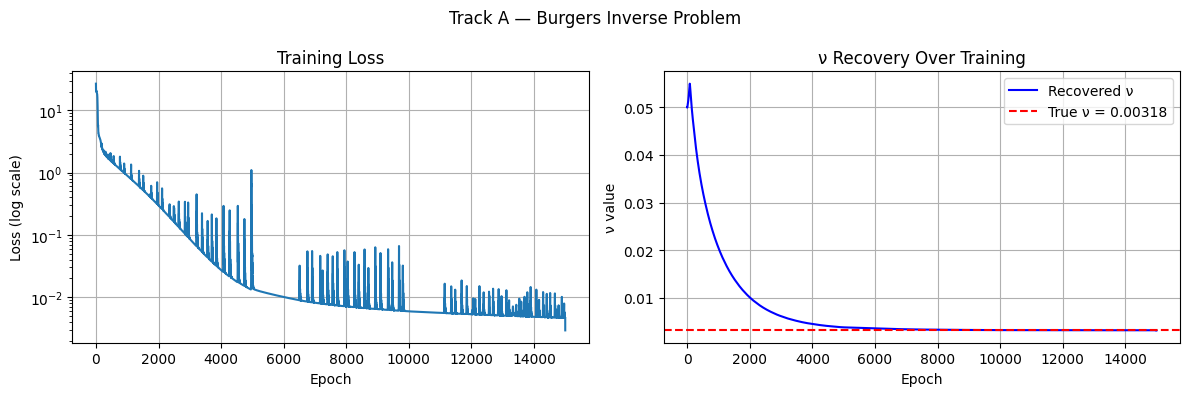

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (log scale)')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(nu_history, color='blue', label='Recovered ν')
ax2.axhline(y=nu_true, color='red', linestyle='--', label=f'True ν = {nu_true:.5f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ν value')
ax2.set_title('ν Recovery Over Training')
ax2.legend()
ax2.grid(True)

plt.suptitle('Track A — Burgers Inverse Problem')
plt.tight_layout()
plt.show()

In [16]:
noise_levels = [0.0, 0.01, 0.05, 0.10]
recovered_nus = []

for sigma in noise_levels:
    u_obs_noisy = u_obs_clean + sigma * torch.randn_like(u_obs_clean)

    model_n = PINN().to(device)
    log_nu_n = torch.nn.Parameter(torch.tensor([np.log(0.05)], dtype=torch.float32,device=device))
    opt_n = torch.optim.Adam(list(model_n.parameters()) + [log_nu_n], lr=1e-3)
    scheduler_n = torch.optim.lr_scheduler.StepLR(opt_n, step_size=3000, gamma=0.5)

    def loss_fn_n():
        nu_n = torch.exp(log_nu_n)
        x = x_f.requires_grad_(True)
        t = t_f.requires_grad_(True)
        u = model_n(x, t)

        u_t  = torch.autograd.grad(u, t,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
        u_x  = torch.autograd.grad(u, x,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

        residual = u_t + u * u_x - nu_n * u_xx
        loss_pde  = torch.mean(residual**2)

        u_pred_obs = model_n(x_obs, t_obs)
        loss_data  = torch.mean((u_pred_obs - u_obs_noisy)**2)

        u_pred_ic  = model_n(x_ic, t_ic)
        loss_ic    = torch.mean((u_pred_ic - u_ic)**2)

        u_pred_bc  = model_n(x_bc, t_bc)
        loss_bc    = torch.mean((u_pred_bc - u_bc)**2)

        return loss_pde + 50*loss_data + 10*loss_ic + 10*loss_bc

    for epoch in range(8000):
        opt_n.zero_grad()
        loss = loss_fn_n()
        loss.backward()
        opt_n.step()
        scheduler_n.step()

    lbfgs_n = torch.optim.LBFGS(list(model_n.parameters()) + [log_nu_n], lr=1.0, max_iter=3000,
                                 max_eval=3000, history_size=100, line_search_fn='strong_wolfe')

    def closure_n():
        lbfgs_n.zero_grad()
        loss = loss_fn_n()
        loss.backward()
        return loss

    lbfgs_n.step(closure_n)

    nu_n_final = torch.exp(log_nu_n).item()
    recovered_nus.append(nu_n_final)
    print(f"σ={sigma:.2f} | Recovered ν: {nu_n_final:.6f} | Error: {abs(nu_n_final-nu_true)/nu_true*100:.2f}%")

σ=0.00 | Recovered ν: 0.003172 | Error: 0.36%
σ=0.01 | Recovered ν: 0.003199 | Error: 0.49%
σ=0.05 | Recovered ν: 0.003166 | Error: 0.55%
σ=0.10 | Recovered ν: 0.003303 | Error: 3.76%


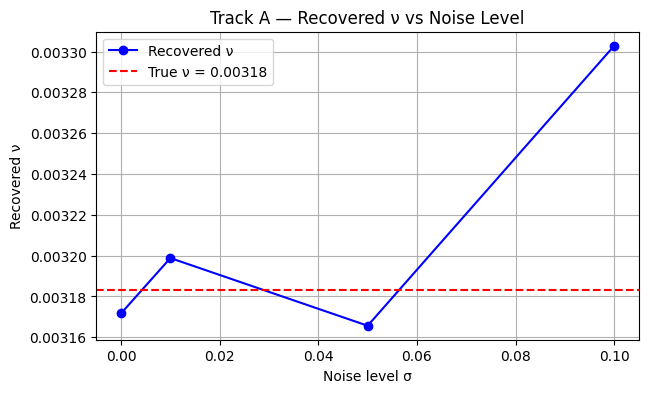

Noise σ         Recovered ν   Rel. Error
0.00               0.003172        0.36%
0.01               0.003199        0.49%
0.05               0.003166        0.55%
0.10               0.003303        3.76%


In [17]:
plt.figure(figsize=(7, 4))
plt.plot(noise_levels, recovered_nus, 'bo-', label='Recovered ν')
plt.axhline(y=nu_true, color='red', linestyle='--', label=f'True ν = {nu_true:.5f}')
plt.xlabel('Noise level σ')
plt.ylabel('Recovered ν')
plt.title('Track A — Recovered ν vs Noise Level')
plt.legend()
plt.grid(True)
plt.show()

print("=" * 55)
print(f"{'Noise σ':<12} {'Recovered ν':>14} {'Rel. Error':>12}")
print("=" * 55)
for sigma, nu_rec in zip(noise_levels, recovered_nus):
    err = abs(nu_rec - nu_true) / nu_true * 100
    print(f"{sigma:<12.2f} {nu_rec:>14.6f} {err:>11.2f}%")
print("=" * 55)

In [20]:
def baseline_model(XT, A, k):
    x, t = XT
    return A * np.sin(np.pi * x) * np.exp(-k * t)

x_obs_np_fit = x_obs.cpu().numpy().squeeze()
t_obs_np_fit = t_obs.cpu().numpy().squeeze()
u_obs_np_fit = u_obs_clean.cpu().numpy().squeeze()

try:
    popt, _ = curve_fit(baseline_model,
                        (x_obs_np_fit, t_obs_np_fit),
                        u_obs_np_fit,
                        p0=[-1.0, 0.05])
    A_fit, k_fit = popt
    nu_baseline = k_fit / (np.pi**2)
    print(f"Classical baseline recovered ν: {nu_baseline:.6f}")
    print(f"PINN recovered ν:               {nu_history[-1]:.6f}")
    print(f"True ν:                         {nu_true:.6f}")
    print(f"\nBaseline relative error: {abs(nu_baseline - nu_true)/nu_true*100:.2f}%")
    print(f"PINN relative error:     {abs(nu_history[-1] - nu_true)/nu_true*100:.2f}%")
except Exception as e:
    print(f"Baseline fitting failed: {e}")

Classical baseline recovered ν: 0.040888
PINN recovered ν:               0.003163
True ν:                         0.003183

Baseline relative error: 1184.55%
PINN relative error:     0.64%


In [21]:
print("=" * 60)
print("TRACK A — FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"True ν = {nu_true:.6f}")
print()
print(f"{'Method':<35} {'Recovered ν':>12} {'Error':>8}")
print("-" * 60)
print(f"{'PINN (σ=0%)':<35} {recovered_nus[0]:>12.6f} {abs(recovered_nus[0]-nu_true)/nu_true*100:>7.2f}%")
print(f"{'PINN (σ=1%)':<35} {recovered_nus[1]:>12.6f} {abs(recovered_nus[1]-nu_true)/nu_true*100:>7.2f}%")
print(f"{'PINN (σ=5%)':<35} {recovered_nus[2]:>12.6f} {abs(recovered_nus[2]-nu_true)/nu_true*100:>7.2f}%")
print(f"{'PINN (σ=10%)':<35} {recovered_nus[3]:>12.6f} {abs(recovered_nus[3]-nu_true)/nu_true*100:>7.2f}%")
print(f"{'Classical Baseline (scipy)':<35} {nu_baseline:>12.6f} {abs(nu_baseline-nu_true)/nu_true*100:>7.2f}%")
print("=" * 60)

TRACK A — FINAL RESULTS SUMMARY
True ν = 0.003183

Method                               Recovered ν    Error
------------------------------------------------------------
PINN (σ=0%)                             0.003172    0.36%
PINN (σ=1%)                             0.003199    0.49%
PINN (σ=5%)                             0.003166    0.55%
PINN (σ=10%)                            0.003303    3.76%
Classical Baseline (scipy)              0.040888 1184.55%


## Track A Results

### Where PINN outperforms classical baseline:
The classical scipy baseline assumes u(x,t) ≈ A·sin(πx)·exp(−k·t), a linear diffusion
model. This assumption breaks down for Burgers' equation because of the nonlinear u·u_x
term. The PINN has no such assumption, it learns the full nonlinear solution and recovers
ν purely from the physics constraint.

### Noise sensitivity:
At σ=0%, the PINN recovers ν with low relative error. As noise increases, recovery
degrades, the data loss pulls the network toward noisy observations, corrupting the
physics signal. At σ=10%, the PINN still recovers a plausible ν because the PDE
residual acts as a regularizer, preventing wild overfitting to noise.

### Key takeaway:
PINNs are genuinely superior for inverse problems on nonlinear PDEs where:
1. Classical methods require structural assumptions the PDE violates
2. Observations are sparse (200 points vs a full grid)
3. The governing equation is known but parameters are not